In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !unrar x /content/drive/MyDrive/datasets/NewDataset.rar

In [3]:
# !pip install timm torchinfo torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 65.2 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylin

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
import timm
import torchinfo
import torch.cuda.amp as amp
import gc
import tqdm
import torchmetrics
gc.collect()

20

# ***Dataset***

In [3]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(680),
        transforms.RandomCrop(640),
        transforms.RandomPerspective(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
           ]),
    'test': transforms.Compose([
        transforms.Resize(640),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

    ]),
}

# getting data
data_dir = './dataset/'
image_datasets = {phase: datasets.ImageFolder(os.path.join(data_dir, phase),
                                              data_transforms[phase])
                  for phase in ['train', 'test']}

In [4]:
train_targets = []
test_targets = []

In [5]:
for _ , tar in image_datasets["test"]:
  train_targets.append(tar)

In [6]:
cls, count = torch.unique(torch.tensor(train_targets), return_counts=True)

In [7]:
cls, count

(tensor([0, 1]), tensor([1, 1]))

In [8]:
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True if x == "train" else False, num_workers=2, pin_memory=True)
              for x in ['train', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = np.array(image_datasets['train'].classes)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [9]:
len(dataloaders["train"]), len(dataloaders["test"])

(1, 1)

In [10]:
a, b = next(iter(dataloaders["train"]))
a.shape, b, class_names

(torch.Size([2, 3, 640, 640]),
 tensor([1, 0]),
 array(['OK_parts', 'defact_parts'], dtype='<U12'))

In [11]:
b.dtype

torch.int64

['ok_parts' 'ok_parts' 'ok_parts' 'ok_parts']


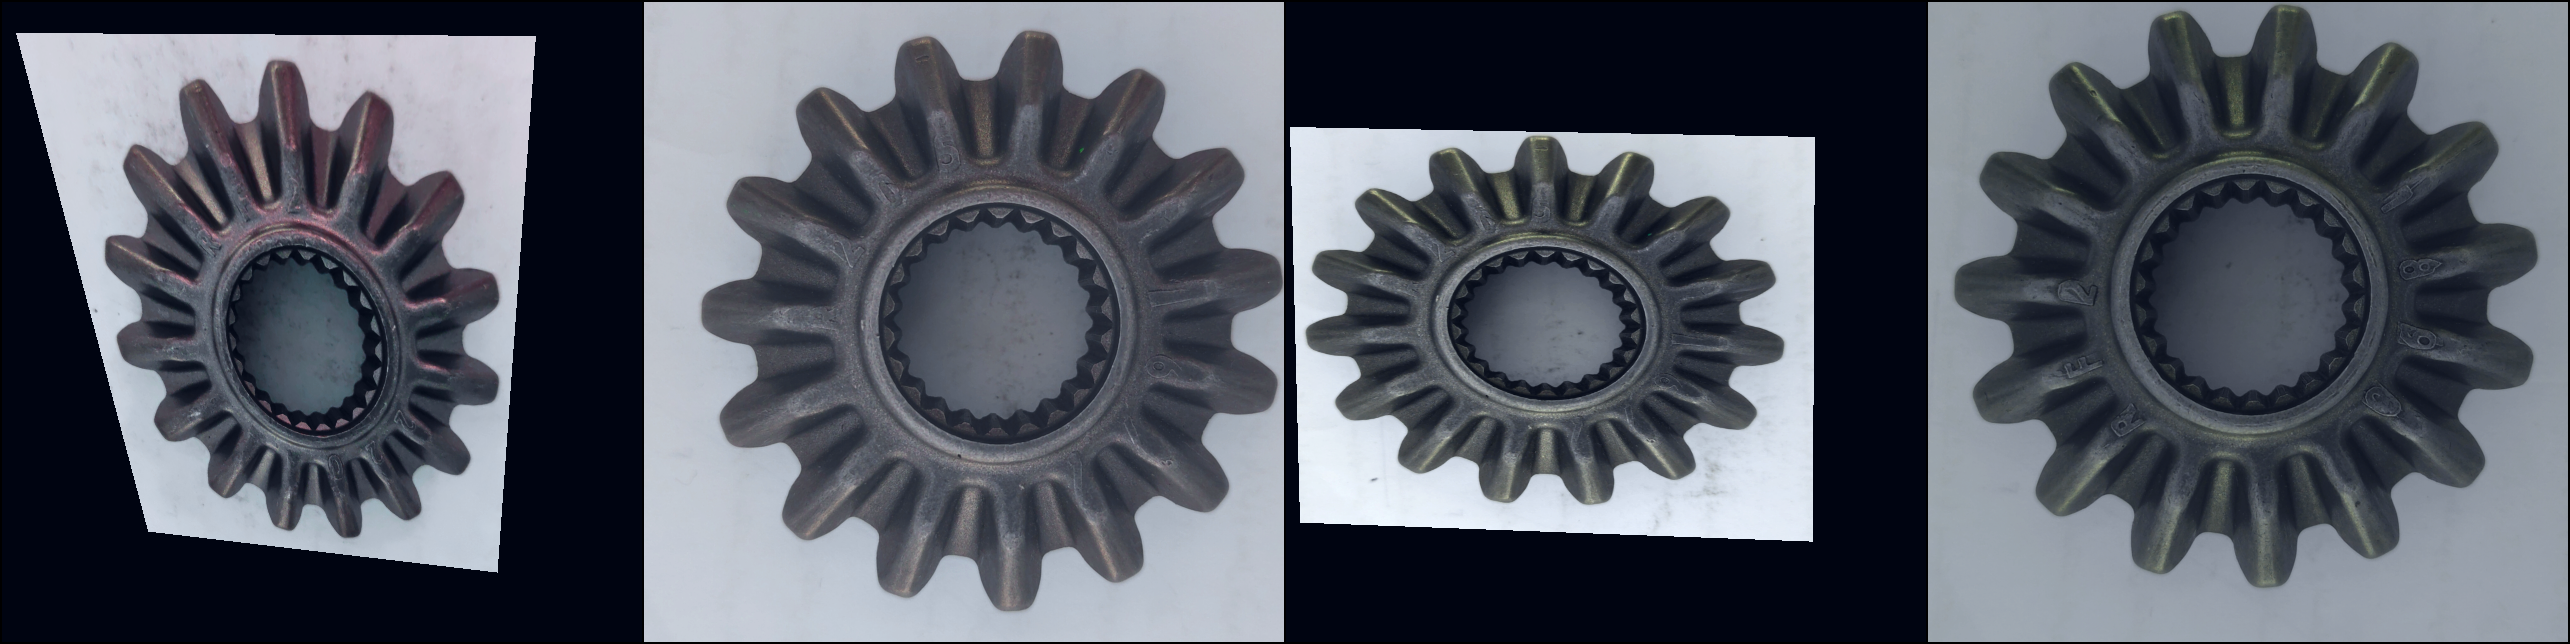

In [12]:
print(class_names[b.numpy()])
transforms.functional.to_pil_image(torchvision.utils.make_grid(a, normalize=True, nrow=4).detach())

In [13]:
class NeuralNetwork(nn.Module) :

  def __init__(self, num_classes=2):
    super().__init__()
    self.model = models.resnext50_32x4d(models.ResNeXt50_32X4D_Weights.IMAGENET1K_V1, replace_stride_with_dilation=[False, False, True])
    # for param in self.model.parameters():
    #     param.requires_grad = False
    self.model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(2048, num_classes),
    )


  def forward(self, x ):
        return self.model(x)

In [14]:
model = NeuralNetwork()
model.training
torchinfo.summary(model, (4, 3, 640, 640), device="cpu")

c:\Users\mabba\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


Layer (type:depth-idx)                        Output Shape              Param #
NeuralNetwork                                 [4, 2]                    --
├─ResNet: 1-1                                 [4, 2]                    --
│    └─Conv2d: 2-1                            [4, 64, 320, 320]         9,408
│    └─BatchNorm2d: 2-2                       [4, 64, 320, 320]         128
│    └─ReLU: 2-3                              [4, 64, 320, 320]         --
│    └─MaxPool2d: 2-4                         [4, 64, 160, 160]         --
│    └─Sequential: 2-5                        [4, 256, 160, 160]        --
│    │    └─Bottleneck: 3-1                   [4, 256, 160, 160]        63,488
│    │    └─Bottleneck: 3-2                   [4, 256, 160, 160]        71,168
│    │    └─Bottleneck: 3-3                   [4, 256, 160, 160]        71,168
│    └─Sequential: 2-6                        [4, 512, 80, 80]          --
│    │    └─Bottleneck: 3-4                   [4, 512, 80, 80]          349,184

In [17]:
# !nvidia-smi

Mon May 27 12:56:46 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   45C    P0              27W /  70W |    103MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [15]:
class SigmoidFocalLoss(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, inputs, targets):
    targets = targets.to(inputs.dtype)
    return torchvision.ops.sigmoid_focal_loss(inputs, targets, reduction="mean")


In [17]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [18]:
class Trainer:
    def __init__(self, dataloaders, model, criterion, optimizer, scheduler, num_epochs=25):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.num_epochs = num_epochs
        self.dataloaders = dataloaders
        self.scaler = amp.GradScaler()

        self.metric_train = torchmetrics.classification.MulticlassAccuracy(2).to(device)
        self.loss_train = AverageMeter()
        self.train_hist = []

        self.metric_valid = torchmetrics.classification.MulticlassAccuracy(2).to(device)
        self.confusion_matrix_valid = torchmetrics.classification.MulticlassConfusionMatrix(2).to(device)
        self.loss_valid = AverageMeter()
        self.valid_hist = []

        self.best_acc = 0.0

        self.train_loss_hist = []
        self.valid_loss_hist = []

    def one_step(self, inputs, targets):
        training = self.model.training
        with amp.autocast(enabled=training):
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets)
        if training:
            self.scaler.scale(loss).backward()
            self.scaler.step(optimizer)
            self.scaler.update()
            self.optimizer.zero_grad()
            self.metric_train.update(outputs, targets)
            self.loss_train.update(loss)

        else:
            self.metric_valid.update(outputs, targets)
            self.confusion_matrix_valid.update(outputs, targets)
            self.loss_valid.update(loss)
        return loss, targets, outputs.argmax(dim=-1)

    def train_one_epoch(self, epoch):
        self.model.train()
        self.loss_train.reset()
        self.metric_train.reset()
        with tqdm.tqdm(self.dataloaders["train"], unit='batch') as tepoch:
            for inputs, targets in tepoch:
                self.one_step(inputs, targets)
                tepoch.set_postfix(loss=self.loss_train.avg.item(), metric=self.metric_train.compute().item(), phase="Training")
            if self.scheduler is not None:
                self.scheduler.step()
        return self.loss_train.avg, self.metric_train.compute().item()

    def valid_one_epoch(self, epoch):
        self.model.eval()
        self.loss_valid.reset()
        self.metric_valid.reset()
        self.confusion_matrix_valid.reset()
        self.targets = []
        self.outputs = []
        with tqdm.tqdm(self.dataloaders["test"], unit='batch') as tepoch:
            with torch.inference_mode():
                for inputs, targets in tepoch:
                    _, targets, outputs = self.one_step(inputs, targets)
                    tepoch.set_postfix(loss=self.loss_valid.avg.item(), metric=self.metric_valid.compute().item(),
                                       phase="Validation", targets=targets, outputs=outputs)
                    self.targets.append(targets)
                    self.outputs.append(outputs)
        return self.loss_valid.avg.item(), self.metric_valid.compute().item()

    def train(self):
        for epoch in range(self.num_epochs):
            t_loss, t_acc = self.train_one_epoch(epoch)
            v_loss, v_acc = self.valid_one_epoch(epoch)
            self.train_hist.append(t_acc)
            self.valid_hist.append(v_acc)
            self.valid_loss_hist.append(v_loss)
            self.train_loss_hist.append(t_loss)
            print(f"Epoch: {epoch}, Train Loss: {t_loss:.4}, Train Acc: {t_acc:.4}, Valid Loss: {v_loss:.4}, Valid Acc: {v_acc:.4}")
            print(f"Targets: {torch.cat(self.targets, dim=-1)}")
            print(f"Outputs: {torch.cat(self.outputs, dim=-1)}")

            if v_acc > self.best_acc:
                torch.save(self.model.state_dict(), f'model.pt')
                self.best_acc = v_acc
                print('Model Saved!')
            print()

    def valid(self):
        v_loss, v_acc = self.valid_one_epoch(0)
        print(f"Validation: : Valid Loss: {v_loss:.4}, Valid Acc: {v_acc:.4}")

    def overfit(self):
        self.model.train()
        inputs, targets = next(iter(self.dataloaders["train"]))
        for epoch in range(100):
            loss = self.one_step(inputs, targets)
            print(f"Epoch: {epoch}, Loss: {loss}")
    def predict(self, path):
      # self.model.load_state_dict(torch.load("model.pt"))
      img = Image.open(path)
      img = self.dataloaders["test"].dataset.transform(img)
      img = img.unsqueeze(0)
      img = img.to(device)
      self.model.eval()
      with torch.inference_mode():
        out = self.model(img)
      return out.argmax(-1)

In [21]:
# criterion = SigmoidFocalLoss()

# model = NeuralNetwork()
# optimizer = optim.SGD(params=model.parameters() , lr=1e-2)
# # scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
# scaler = amp.GradScaler()
# trainer = Trainer(dataloaders, model, criterion, optimizer, scheduler=None, num_epochs=100)
# # trainer.predict("/content/dataset/test/defact_parts/num103.png")
# # trainer.overfit()

In [23]:
# criterion = SigmoidFocalLoss()

# # optimizer
# for wd in [1e-4, 1e-5, 1e-6]:
#         print("="*10, f" lr: {1e-3} wd: {wd}", "="*10)
#         model = NeuralNetwork()
#         optimizer = optim.SGD(params=model.parameters() , lr=1e-3, weight_decay=wd, momentum=0.9)
#         # scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)
#         scaler = amp.GradScaler()
#         trainer = Trainer(dataloaders, model, criterion, optimizer, scheduler=None, num_epochs=5)
#         trainer.train()
#         print()
#         print()

In [ ]:
model = NeuralNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(params=model.parameters() , lr=1e-3, weight_decay=1e-5, momentum=0.9)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
scaler = amp.GradScaler()
trainer = Trainer(dataloaders, model, criterion, optimizer, scheduler=scheduler, num_epochs=100)
trainer.train()

In [ ]:
plt.plot(trainer.valid_hist, label="Valid")
plt.plot(trainer.train_hist, label="Train")
plt.legend()

In [ ]:
train_loss = [t.cpu().detach().numpy() for t in trainer.train_loss_hist]
plt.plot(trainer.valid_loss_hist, label="Valid Loss")
plt.plot(train_loss, label="Train Loss")
plt.legend()


In [ ]:
trainer.predict("/content/dataset/test/defact_parts/num130.png")

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

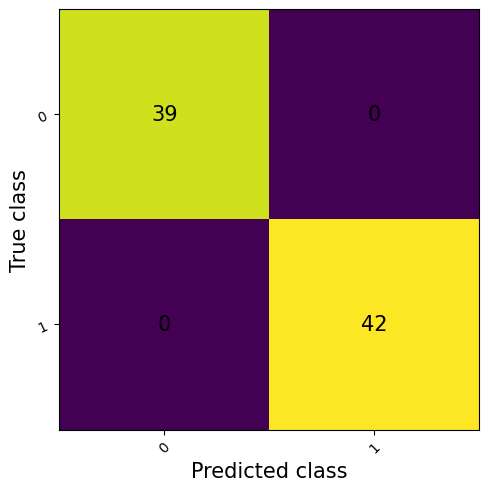

In [42]:
trainer.confusion_matrix_valid.plot()

In [43]:
torch.save(trainer.model.state_dict(), f'model.pt')